In [1]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

using CUDA
using cuDNN
CUDA.allowscalar(true)
println("CUDA.functional() = ", CUDA.functional())

using Random
using JLD2
using Flux
using Flux: onehotbatch, onecold
using MLUtils: DataLoader
using Statistics
using Printf
import StatisticalMeasures
using StatisticalMeasures: macro_avg, micro_avg
import StatisticalMeasures.ConfusionMatrices as CM

  Activating project at `~/Dokumente/BA2/notebooks/model_train`
┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
│ Please consider using an official build from https://julialang.org/downloads/.
└ @ CUDA /home/benjamin/.julia/packages/CUDA/x8d2s/src/initialization.jl:170
┌ Warning: It's not recommended to use allowscalar([true]) to allow scalar indexing.
│ Instead, use `allowscalar() do end` or `@allowscalar` to denote exactly which operations can use scalar operations.
└ @ GPUArraysCore /home/benjamin/.julia/packages/GPUArraysCore/aNaXo/src/GPUArraysCore.jl:184


CUDA.functional() = true


In [2]:
use_gpu = CUDA.functional()

device(x) = use_gpu ? cu(x) : x
device_name = use_gpu ? "GPU (CUDA)" : "CPU"

println("Device: ", device_name)

Device: GPU (CUDA)


In [3]:
using CUDA
CUDA.versioninfo()
CUDA.functional()

CUDA toolchain: 
- runtime 13.0, artifact installation
- driver 590.48.1 for 13.1
- compiler 13.1

CUDA libraries: 
- CUBLAS: 13.1.0
- CURAND: 10.4.0
- CUFFT: 12.0.0
- CUSOLVER: 12.0.4
- CUSPARSE: 12.6.3
- CUPTI: 2025.3.1 (API 13.0.1)
- NVML: 13.0.0+590.48.1

Julia packages: 
- CUDA: 5.9.5
- CUDA_Driver_jll: 13.1.0+0
- CUDA_Compiler_jll: 0.3.0+1
- CUDA_Runtime_jll: 0.19.2+0

Toolchain:
- Julia: 1.12.3
- LLVM: 18.1.7

1 device:
  0: NVIDIA GeForce RTX 4070 (sm_89, 10.090 GiB / 11.994 GiB available)


true

In [4]:
dataset_dir = abspath(joinpath(pwd(), "..", "datasets"))


# Return most recent .jld2 file in a directory.
function latest_jld2(dir)
    files = filter(f -> endswith(f, ".jld2"), readdir(dir; join=true))
    isempty(files) && error("No .jld2 files found in ", dir)
    return sort(files; by=mtime)[end]
end

# Fetch a setting from NamedTuple or Dict.
function get_setting(settings, key, default)
    if settings isa NamedTuple
        return hasproperty(settings, key) ? getproperty(settings, key) : default
    elseif settings isa AbstractDict
        return get(settings, key, get(settings, String(key), default))
    else
        return default
    end
end

dataset_path = latest_jld2(dataset_dir)
raw = JLD2.load(dataset_path)
images = raw["images"]
labels = raw["labels"]
metadata = raw["metadata"]
settings = get(raw, "settings", NamedTuple())
pattern_names = get_setting(settings, :pattern_names, unique(labels))
pattern_names = Symbol.(pattern_names)
if :noclass in pattern_names && !(:no_class in pattern_names)
    pattern_names = map(p -> p == :noclass ? :no_class : p, pattern_names)
end
variant_names = get_setting(settings, :variant_names, nothing)
variant_names = variant_names === nothing ? nothing : Symbol.(variant_names)

println("Loaded: ", dataset_path)
println("Images: ", length(images), ", Labels: ", length(labels), ", Metadata: ", length(metadata))
println("Classes: ", pattern_names)
println("Variants: ", variant_names === nothing ? "none" : variant_names)


Loaded: /home/benjamin/Dokumente/BA2/notebooks/datasets/erp_dataset_20260108_230803.jld2
Images: 7000, Labels: 7000, Metadata: 7000
Classes: [:sigmoid, :one_sided_fan, :two_sided_fan, :diverging_bar, :hourglass, :tilted_bar, :noclass]


In [5]:
# Stack ERP images into a 4D tensor.
function images_to_tensor(imgs)
    h, w = size(imgs[1])
    n = length(imgs)
    x = Array{Float32}(undef, h, w, 1, n)
    for (i, img) in enumerate(imgs)
        x[:, :, 1, i] = Float32.(img)
    end
    return x
end

X = images_to_tensor(images)
N = size(X, 4)

labels_sym = Symbol.(labels)
if :noclass in labels_sym
    labels_sym = map(l -> l == :noclass ? :no_class : l, labels_sym)
end
if :noclass in pattern_names && !(:no_class in pattern_names)
    pattern_names = map(p -> p == :noclass ? :no_class : p, pattern_names)
end

label_to_id = Dict(p => i - 1 for (i, p) in enumerate(pattern_names))
label_ids = [label_to_id[lbl] for lbl in labels_sym]
Y = onehotbatch(label_ids, 0:length(pattern_names)-1) |> Array{Float32}

# Group-aware split to keep derived variants together.
get_meta(meta::NamedTuple, key::Symbol) = hasproperty(meta, key) ? getproperty(meta, key) : missing
function epoch_duration_or_raw(meta::NamedTuple)
    val = get_meta(meta, :epoch_duration_s)
    if val !== missing
        return val
    end
    raw = get_meta(meta, :erpimage_raw_size)
    return raw === missing ? missing : raw[2]
end
function group_key(meta::NamedTuple)
    return (
        get_meta(meta, :pattern),
        get_meta(meta, :mu),
        get_meta(meta, :sigma),
        epoch_duration_or_raw(meta),
        get_meta(meta, :noise),
        get_meta(meta, :noiselevel),
        get_meta(meta, :sampling_rate),
        get_meta(meta, :crop_start_ms),
        get_meta(meta, :crop_end_ms),
        get_meta(meta, :crop_start_samples),
        get_meta(meta, :crop_end_samples),
    )
end

rng = Random.Xoshiro(time_ns())
group_keys = map(group_key, metadata)
uniq_keys = unique(group_keys)
shuffled_keys = shuffle(rng, uniq_keys)
train_group_n = Int(floor(0.75 * length(shuffled_keys)))
train_group_keys = Set(shuffled_keys[1:train_group_n])
train_idx = findall(k -> k in train_group_keys, group_keys)
test_idx = findall(k -> !(k in train_group_keys), group_keys)


train_X = X[:, :, :, train_idx]
train_Y = Y[:, train_idx]
train_meta = metadata[train_idx]

test_X = X[:, :, :, test_idx]
test_Y = Y[:, test_idx]
test_meta = metadata[test_idx]

println("Train size: ", size(train_X, 4), " | Test size: ", size(test_X, 4))


Train size: 5250 | Test size: 1750


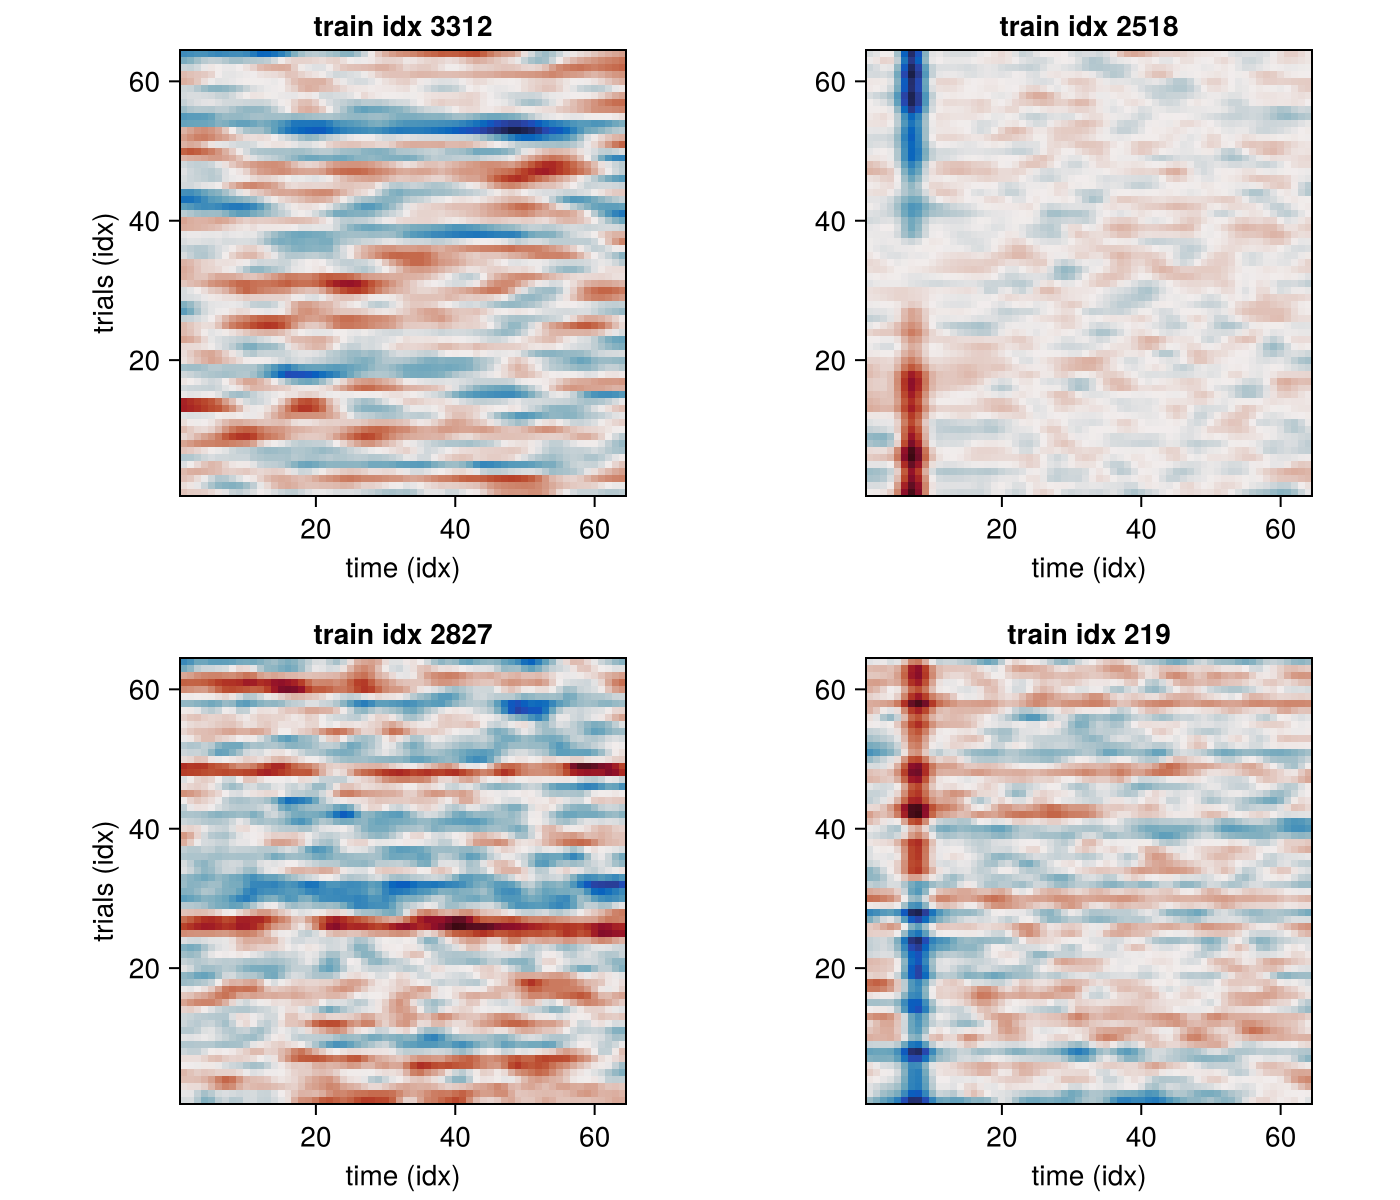

In [6]:
using CairoMakie

# Preview 4 random training ERP images (x=time, y=trials)
@assert size(train_X, 3) == 1 "Expected single-channel ERP images."
rng_preview = Random.Xoshiro(time_ns())
sample_idx = rand(rng_preview, 1:size(train_X, 4), 4)

fig = Figure(size = (700, 600), figure_padding = 5)
for (i, idx) in enumerate(sample_idx)
    row = i <= 2 ? 1 : 2
    col = i <= 2 ? i : i - 2
    img = train_X[:, :, 1, idx]
    vmax = maximum(abs, img)
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)
    ax = Axis(fig[row, col]; title = "train idx " * string(idx), xlabel = "time (idx)", ylabel = (col == 1 ? "trials (idx)" : ""), aspect = AxisAspect(1))
    x = 1:size(img, 2)
    y = 1:size(img, 1)
    heatmap!(ax, x, y, permutedims(img, (2, 1)); colormap = :balance, colorrange = cr)
end
fig


In [7]:
batchsize = 64

train_loader = DataLoader((train_X, train_Y);
    batchsize=batchsize,
    shuffle=true,
)

test_loader = DataLoader((test_X, test_Y);
    batchsize=batchsize,
    shuffle=false,
)

28-element DataLoader(::Tuple{Array{Float32, 4}, Matrix{Float32}}, batchsize=64)
  with first element:
  (64×64×1×64 Array{Float32, 4}, 7×64 Matrix{Float32},)

In [8]:
H, W, C, _ = size(train_X)
n_classes = size(train_Y, 1)

@assert H == 64 && W == 64 "CNN expects 64x64 inputs but got $(H)x$(W)."

block1 = Chain(
    Conv((3, 3), C => 16, pad=1), relu,
    MaxPool((2, 2)),
)

block2 = Chain(
    Conv((3, 3), 16 => 32, pad=1), relu,
    MaxPool((2, 2)),
)

block3 = Chain(
    Conv((3, 3), 32 => 64, pad=1), relu,
    MaxPool((2, 2)),
)

head = Chain(
    Flux.flatten,
    Dense(8 * 8 * 64 => 128, relu),
    Dense(128 => n_classes),
    softmax,
)

model = Chain(block1, block2, block3, head)
model = use_gpu ? gpu(model) : cpu(model)

println("Model on: ", device_name)
println("First conv weight type: ", typeof(model[1][1].weight))

Model on: GPU (CUDA)
First conv weight type: CuArray{Float32, 4, CUDA.DeviceMemory}


In [9]:
loss(m, x, y) = Flux.Losses.crossentropy(m(x), y)

# Compute accuracy for model outputs.
function accuracy(m, x, y)
    yhat = m(x)
    pred = onecold(cpu(yhat), 0:n_classes-1)
    truth = onecold(cpu(y), 0:n_classes-1)
    return mean(pred .== truth)
end

accuracy (generic function with 1 method)

In [10]:
optim = Flux.Adam(1f-3)
opt_state = Flux.setup(optim, model)

nepochs = 10
@info "Training for $nepochs epochs on $device_name"

for epoch in 1:nepochs
    epoch_loss = 0f0
    nbatch = 0

    for (xb_cpu, yb_cpu) in train_loader
        xb = device(xb_cpu)
        yb = device(yb_cpu)

        loss_val, grads = Flux.withgradient(model) do m
            loss(m, xb, yb)
        end

        opt_state, model = Flux.update!(opt_state, model, grads[1])
        epoch_loss += loss_val
        nbatch += 1
    end

    @info "Epoch $epoch: train loss = $(epoch_loss / nbatch)"
end

┌ Info: Training for 10 epochs on GPU (CUDA)
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:5
┌ Info: Epoch 1: train loss = 1.1302072
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:24
┌ Info: Epoch 2: train loss = 0.64684886
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:24
┌ Info: Epoch 3: train loss = 0.48122802
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:24
┌ Info: Epoch 4: train loss = 0.37663656
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:24
┌ Info: Epoch 5: train loss = 0.2930493
└ @ Main /home/benjamin/Dokumente/BA2/notebooks/model_train/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2

In [11]:
CUDA.reclaim()

y_true_all = Int[]
y_pred_all = Int[]

test_scores = Matrix{Float32}(undef, n_classes, size(test_X, 4))
offset = 0

for (xb_cpu, yb_cpu) in test_loader
    xb = device(xb_cpu)
    yhat = cpu(model(xb))

    n = size(yhat, 2)
    test_scores[:, offset+1:offset+n] = yhat
    offset += n

    append!(y_pred_all, onecold(yhat, 0:n_classes-1))
    append!(y_true_all, onecold(yb_cpu, 0:n_classes-1))
end

y_pred = collect(y_pred_all)
y_true = collect(y_true_all)

println("Test samples: ", length(y_true))
println("Example preds: ", y_true[1:min(10, end)], " vs ", y_pred[1:min(10, end)])

Test samples: 1750
Example preds: [3, 3, 3, 1, 2, 4, 1, 5, 2, 0] vs [3, 3, 3, 1, 2, 6, 1, 5, 3, 2]


In [12]:
acc_m = StatisticalMeasures.Accuracy()
mcr_m = StatisticalMeasures.MisclassificationRate()
bacc_m = StatisticalMeasures.BalancedAccuracy()
macroF1_m = StatisticalMeasures.MulticlassFScore(; average=macro_avg)
microF1_m = StatisticalMeasures.MulticlassFScore(; average=micro_avg)
prec_m = StatisticalMeasures.MulticlassPositivePredictiveValue()
rec_m = StatisticalMeasures.MulticlassTruePositiveRate()
kap_m = StatisticalMeasures.Kappa()
cm_m = StatisticalMeasures.ConfusionMatrix()

acc = acc_m(y_pred, y_true)
mcr = mcr_m(y_pred, y_true)
bacc = bacc_m(y_pred, y_true)
macroF1 = macroF1_m(y_pred, y_true)
microF1 = microF1_m(y_pred, y_true)
prec = prec_m(y_pred, y_true)
rec = rec_m(y_pred, y_true)
kap = kap_m(y_pred, y_true)
cm = cm_m(y_pred, y_true)

cm_mat = CM.matrix(cm)
cls_lbls = CM.levels(cm)
K = length(cls_lbls)

println("=== Test Metrics ===")
@printf("Accuracy              : %.4f\n", acc)
@printf("MisclassificationRate : %.4f\n", mcr)
@printf("Balanced Accuracy     : %.4f\n", bacc)
@printf("Macro Precision       : %.4f\n", prec)
@printf("Macro Recall          : %.4f\n", rec)
@printf("Macro F1              : %.4f\n", macroF1)
@printf("Micro F1              : %.4f\n", microF1)
@printf("Cohen's kappa          : %.4f\n", kap)

println("\nConfusion matrix (rows = pred, cols = true):\n")
@printf("%-22s", "pred \\ true")
for lbl in cls_lbls
    @printf("%6d", Int(lbl))
end
println()

for (i, lbl_pred) in enumerate(cls_lbls)
    name_pred = String(pattern_names[Int(lbl_pred)+1])
    @printf("(%d) %-16s", Int(lbl_pred), name_pred[1:min(end, 16)])
    for j in 1:K
        @printf("%6d", cm_mat[i, j])
    end
    println()
end

┌ Warning: Levels not explicitly ordered. Using the order [0, 1, 2, 3, 4, 5, 6]. 
└ @ StatisticalMeasures.ConfusionMatrices /home/benjamin/.julia/packages/StatisticalMeasures/RRiuf/src/confusion_matrices.jl:346


=== Test Metrics ===
Accuracy              : 0.8714
MisclassificationRate : 0.1286
Balanced Accuracy     : 0.8711
Macro Precision       : 0.8742
Macro Recall          : 0.8711
Macro F1              : 0.8721
Micro F1              : 0.8714
Cohen's kappa          : 0.8500

Confusion matrix (rows = pred, cols = true):

pred \ true                0     1     2     3     4     5     6
(0) sigmoid            233     1     3     4     3     6    10
(1) one_sided_fan        1   236     3     6     3     0     6
(2) two_sided_fan        4     1   222     1    11     0     8
(3) diverging_bar        6     5     3   212     4     4    21
(4) hourglass            2     1     5     0   197     2     3
(5) tilted_bar           1     1     7     5     6   227     7
(6) noclass             12     8     6    22    13    10   198


Accuracy by true class
  diverging_bar: 0.848 (n=250)
  hourglass: 0.831 (n=237)
  noclass: 0.783 (n=253)
  one_sided_fan: 0.933 (n=253)
  sigmoid: 0.9 (n=259)
  tilted_bar: 0.912 (n=249)
  two_sided_fan: 0.892 (n=249)

Accuracy by noise type
  UnfoldSim.ExponentialNoise: 0.67 (n=442)
  UnfoldSim.PinkNoise: 0.926 (n=445)
  UnfoldSim.RedNoise: 0.945 (n=419)
  UnfoldSim.WhiteNoise: 0.948 (n=444)

Accuracy by noiselevel
  [1.0, 16.0] -> 0.892 (n=1504)
  [16.0, 31.0] -> 0.756 (n=201)
  [31.0, 46.0] -> 0.737 (n=38)
  [46.0, 61.0] -> 0.571 (n=7)

Accuracy by mu
  [1.0, 2.32] -> 0.837 (n=349)
  [2.32, 3.64] -> 0.885 (n=871)
  [3.64, 4.96] -> 0.876 (n=483)
  [4.96, 6.28] -> 0.83 (n=47)

Accuracy by sigma
  [0.01, 0.271] -> 0.899 (n=218)
  [0.271, 0.532] -> 0.879 (n=760)
  [0.532, 0.793] -> 0.853 (n=634)
  [0.793, 1.054] -> 0.87 (n=138)

Accuracy by maxlength
  [40.0, 80.75] -> 0.843 (n=502)
  [80.75, 121.5] -> 0.882 (n=785)
  [121.5, 162.25] -> 0.889 (n=405)
  [162.25, 203.0] -> 0.862 (n=58)



In [14]:
# Sort and format class scores.
function format_scores(scores, names; topk=length(names))
    pairs = collect(zip(names, scores))
    sort!(pairs; by=x -> x[2], rev=true)
    return pairs[1:min(topk, length(pairs))]
end

format_scores (generic function with 1 method)

Sample index: 772
True label : noclass
Pred label : noclass
Scores:
  noclass => 0.8493
  one_sided_fan => 0.0878
  sigmoid => 0.0506
  diverging_bar => 0.0112
  two_sided_fan => 0.0009
  tilted_bar => 0.0002
  hourglass => 0.0


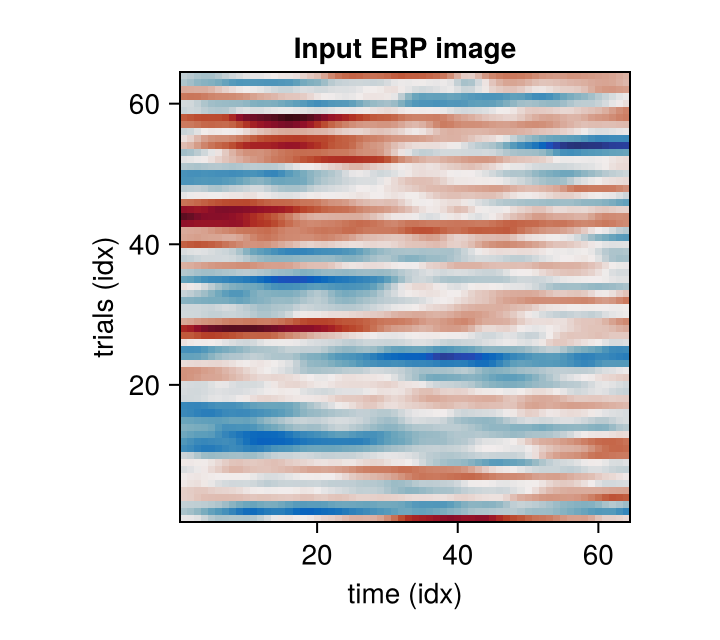

In [15]:
using CairoMakie

sample_idx = rand(1:size(test_X, 4))
sample_img = test_X[:, :, 1, sample_idx]
sample_scores = test_scores[:, sample_idx]

true_lbl = pattern_names[y_true[sample_idx]+1]
pred_lbl = pattern_names[y_pred[sample_idx]+1]
sample_meta = test_meta[sample_idx]

println("Sample index: ", sample_idx)
println("True label : ", true_lbl)
println("Pred label : ", pred_lbl)
if hasproperty(sample_meta, :variant)
    println("Variant   : ", sample_meta.variant)
end
if hasproperty(sample_meta, :trial_order)
    println("Trial order: ", sample_meta.trial_order)
end
if hasproperty(sample_meta, :inverted)
    println("Inverted  : ", sample_meta.inverted)
end
if hasproperty(sample_meta, :sampling_rate)
    println("Sampling  : ", sample_meta.sampling_rate)
end
if hasproperty(sample_meta, :crop_start_ms) && hasproperty(sample_meta, :crop_end_ms)
    println("Crop ms   : ", sample_meta.crop_start_ms, " / ", sample_meta.crop_end_ms)
end
println("Scores:")
for (name, score) in format_scores(sample_scores, pattern_names)
    println("  ", name, " => ", round(score, digits=4))
end

fig = Figure(size=(360, 320))
ax = Axis(fig[1, 1]; title="Input ERP image", xlabel="time (idx)", ylabel="trials (idx)", aspect=AxisAspect(1))
x = 1:size(sample_img, 2)
y = 1:size(sample_img, 1)
vmax = maximum(abs, sample_img)
vmax = vmax == 0 ? 1f-6 : vmax
cr = (-vmax, vmax)
heatmap!(ax, x, y, permutedims(sample_img, (2, 1)); colormap = :balance, colorrange = cr)
fig


Output scores:
  two_sided_fan => 1.0
  hourglass => 0.0
  tilted_bar => 0.0
  one_sided_fan => 0.0
  sigmoid => 0.0
  diverging_bar => 0.0
  noclass => 0.0


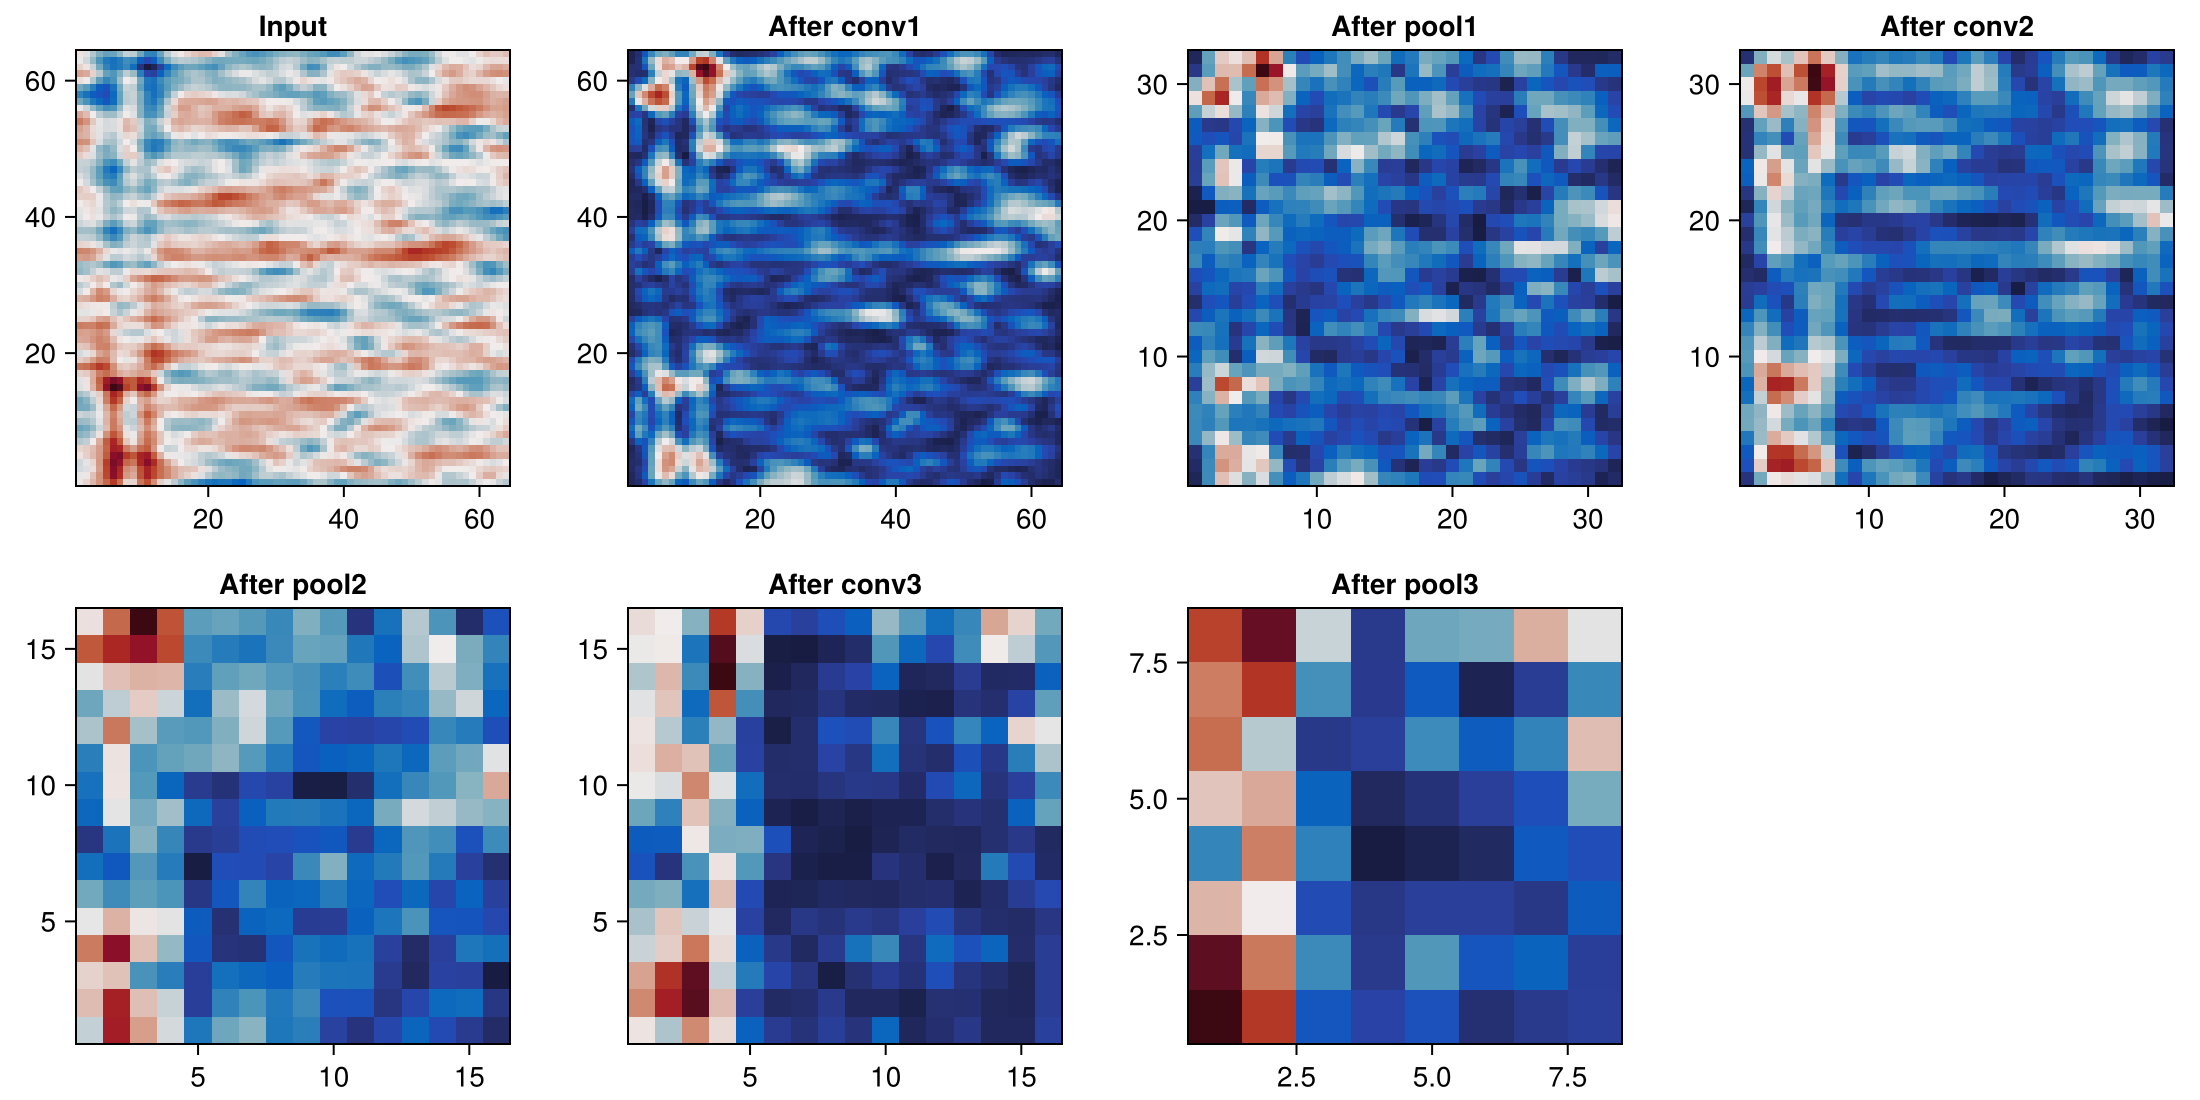

In [16]:
using CairoMakie

sample_idx = rand(1:size(test_X, 4))

x0 = test_X[:, :, :, sample_idx:sample_idx]
x0_dev = device(x0)

block1_dev, block2_dev, block3_dev, head_dev = model[1], model[2], model[3], model[4]
conv1, relu1, pool1 = block1_dev[1], block1_dev[2], block1_dev[3]
conv2, relu2, pool2 = block2_dev[1], block2_dev[2], block2_dev[3]
conv3, relu3, pool3 = block3_dev[1], block3_dev[2], block3_dev[3]

x1c = conv1(x0_dev)
x1 = relu1(x1c)
x1p = pool1(x1)

x2c = conv2(x1p)
x2 = relu2(x2c)
x2p = pool2(x2)

x3c = conv3(x2p)
x3 = relu3(x3c)
x3p = pool3(x3)

scores = cpu(head_dev(x3p))[:, 1]

# Convert a feature tensor to a 2D image.
function to_image(x)
    x_cpu = Array(cpu(x))
    if ndims(x_cpu) == 4
        return dropdims(mean(x_cpu; dims=3), dims=3)[:, :, 1]
    elseif ndims(x_cpu) == 3
        return dropdims(mean(x_cpu; dims=3), dims=3)
    else
        return x_cpu
    end
end

imgs = [
    to_image(x0),
    to_image(x1),
    to_image(x1p),
    to_image(x2),
    to_image(x2p),
    to_image(x3),
    to_image(x3p),
]

titles = [
    "Input",
    "After conv1",
    "After pool1",
    "After conv2",
    "After pool2",
    "After conv3",
    "After pool3",
]

fig = Figure(size=(1100, 550), figure_padding=5)
colgap!(fig.layout, 8)
rowgap!(fig.layout, 8)

for (i, img) in enumerate(imgs)
    row = i <= 4 ? 1 : 2
    col = i <= 4 ? i : (i - 4)
    ax = Axis(fig[row, col]; title=titles[i], aspect=AxisAspect(1))
    heatmap!(ax, permutedims(img, (2, 1)); colormap=:balance)
end

println("Output scores:")
for (name, score) in format_scores(scores, pattern_names)
    println("  ", name, " => ", round(score, digits=4))
end

fig

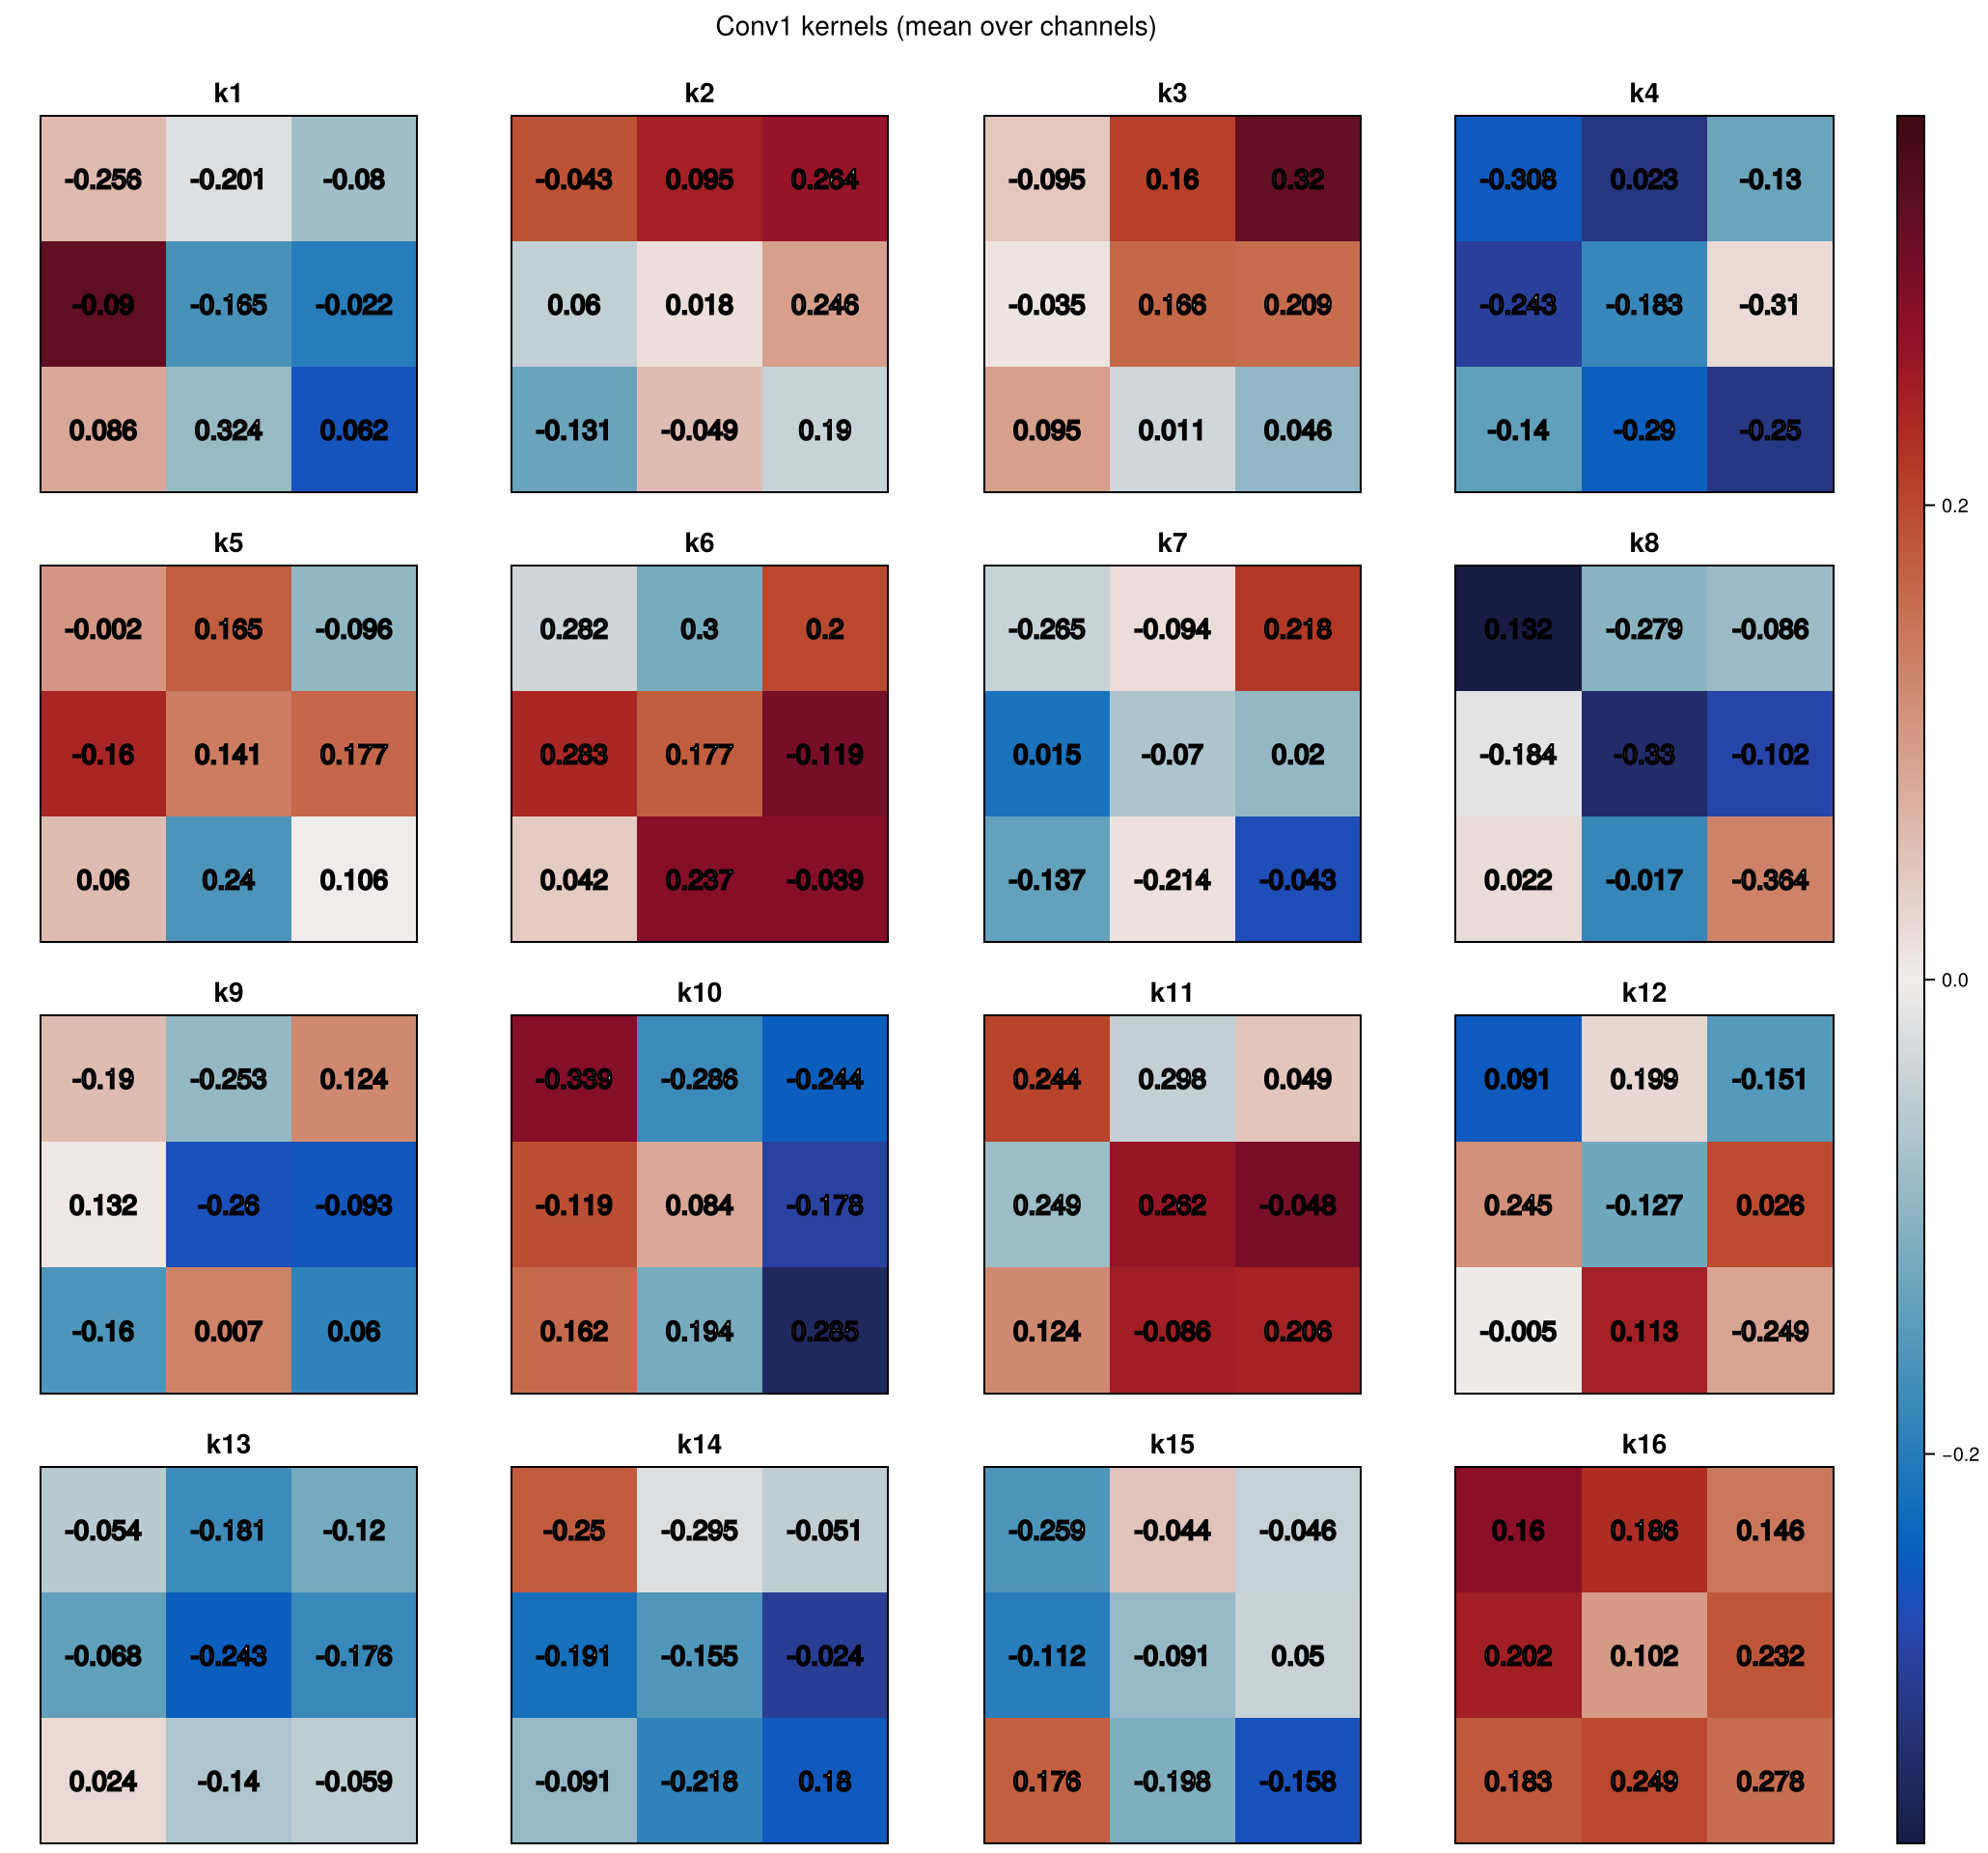

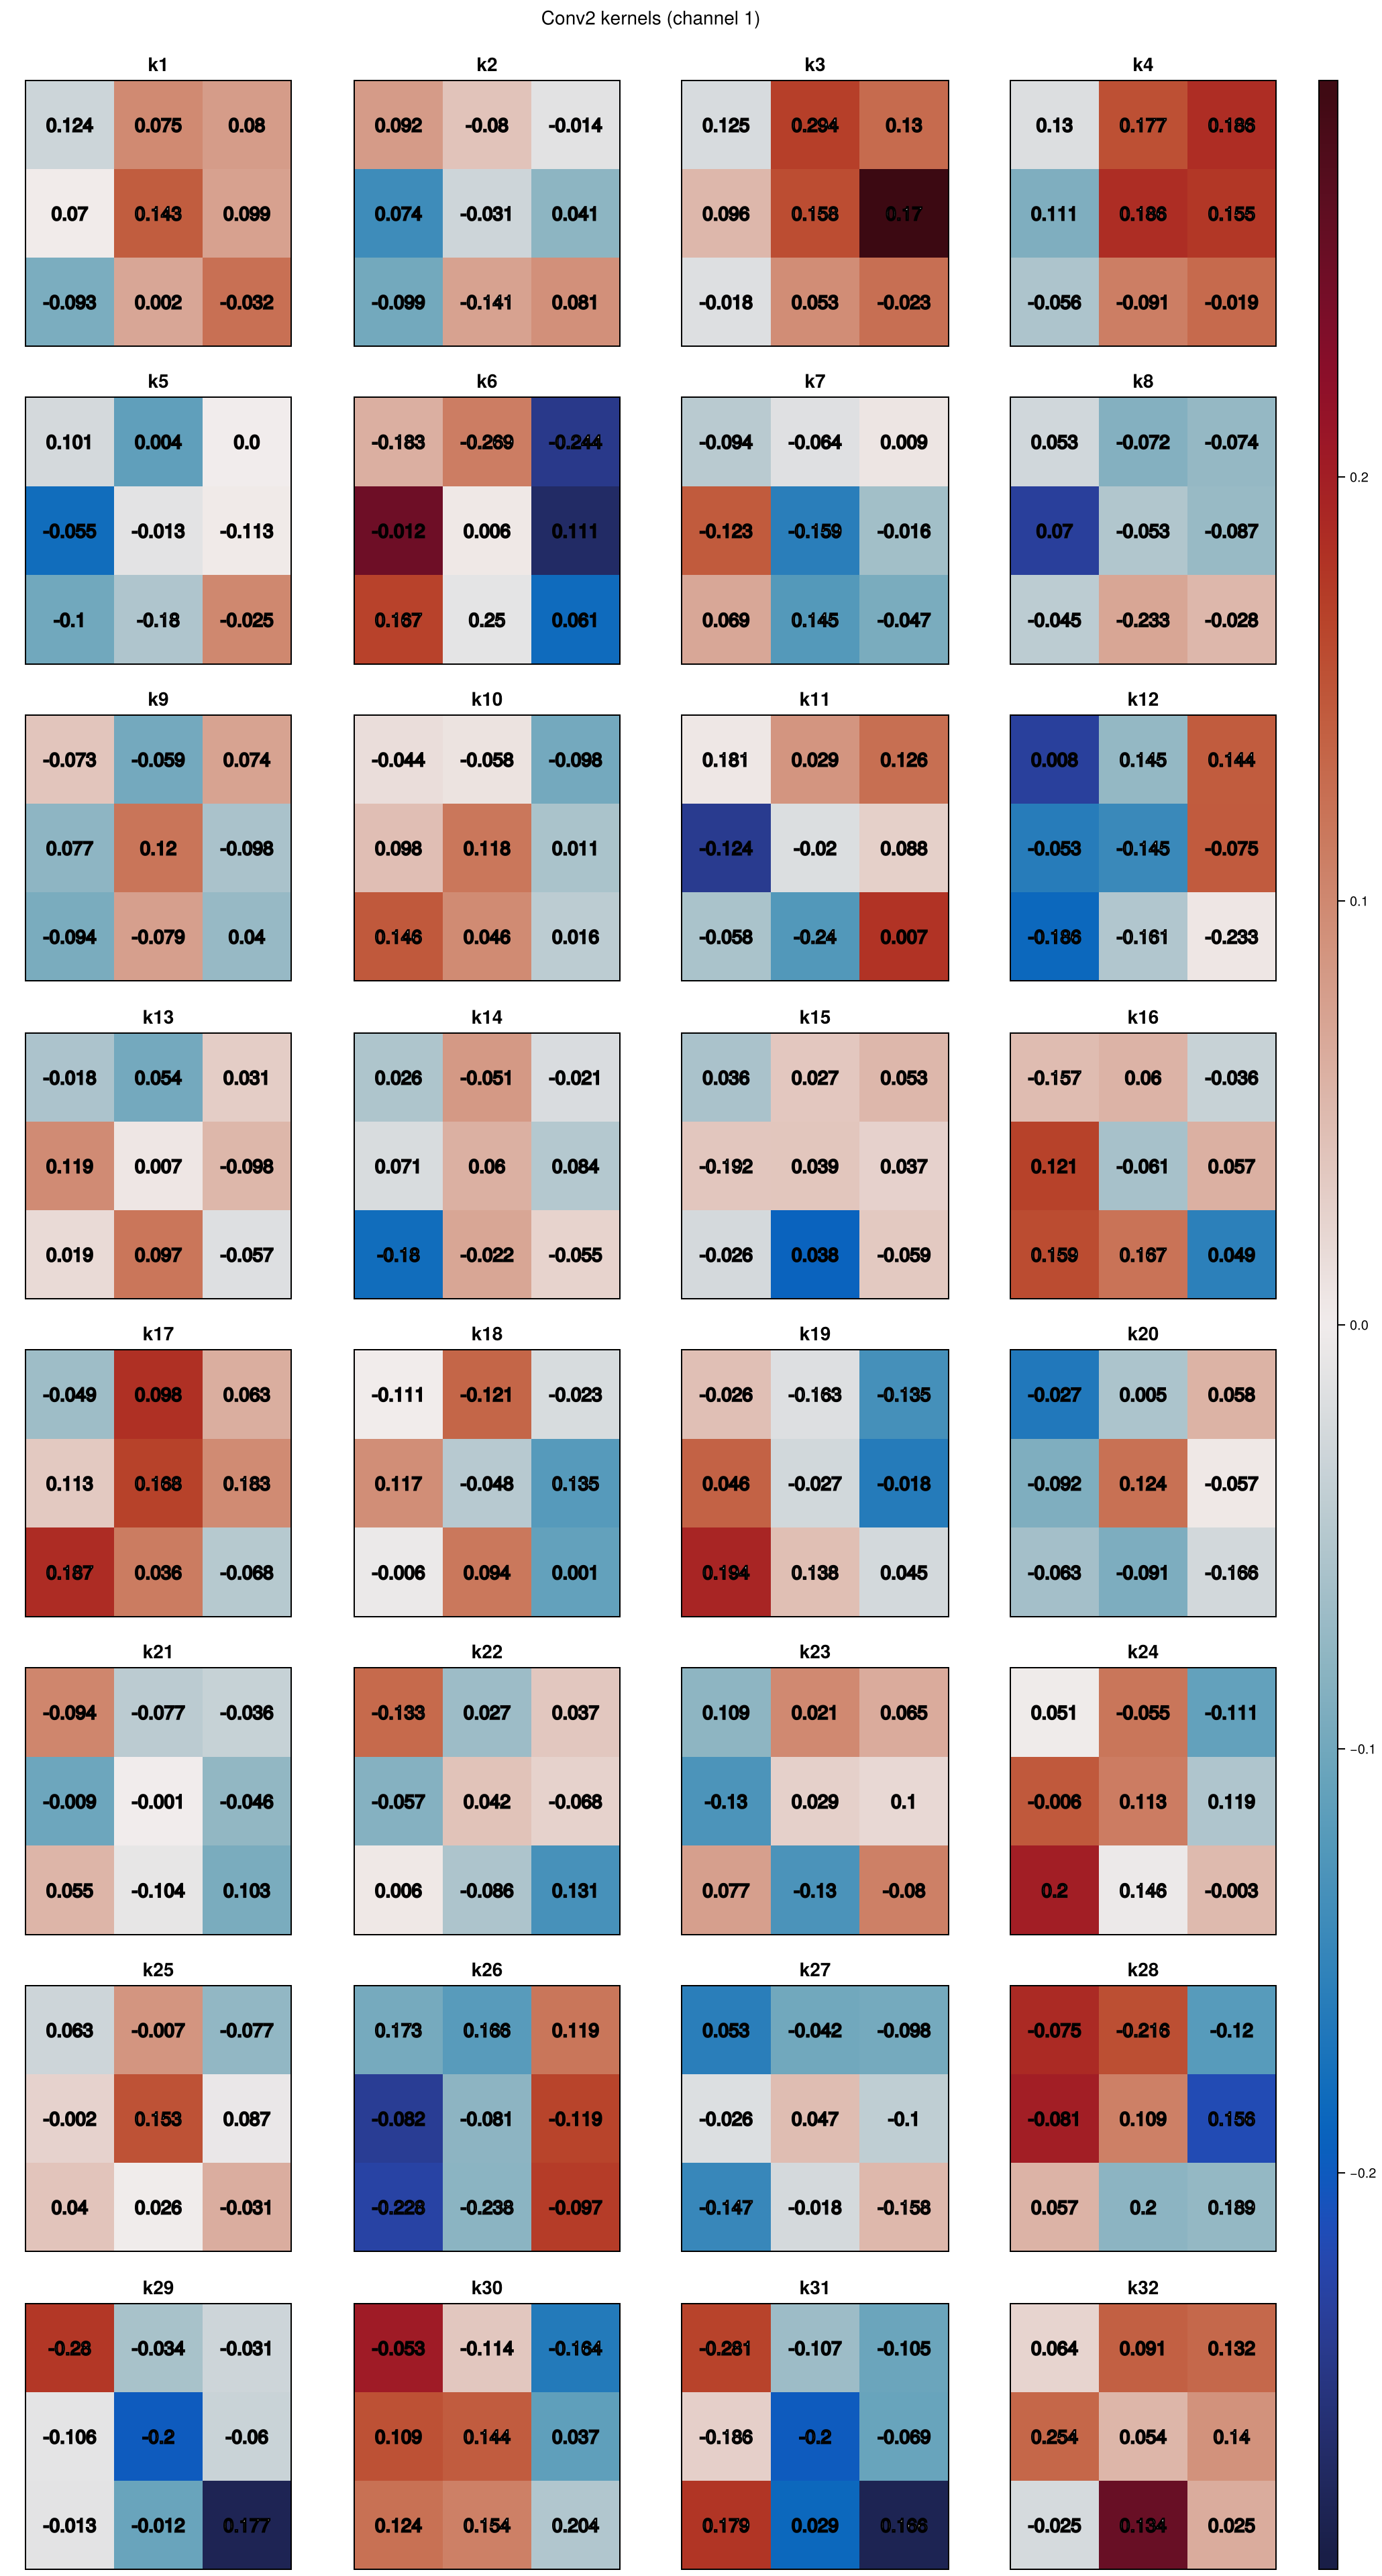

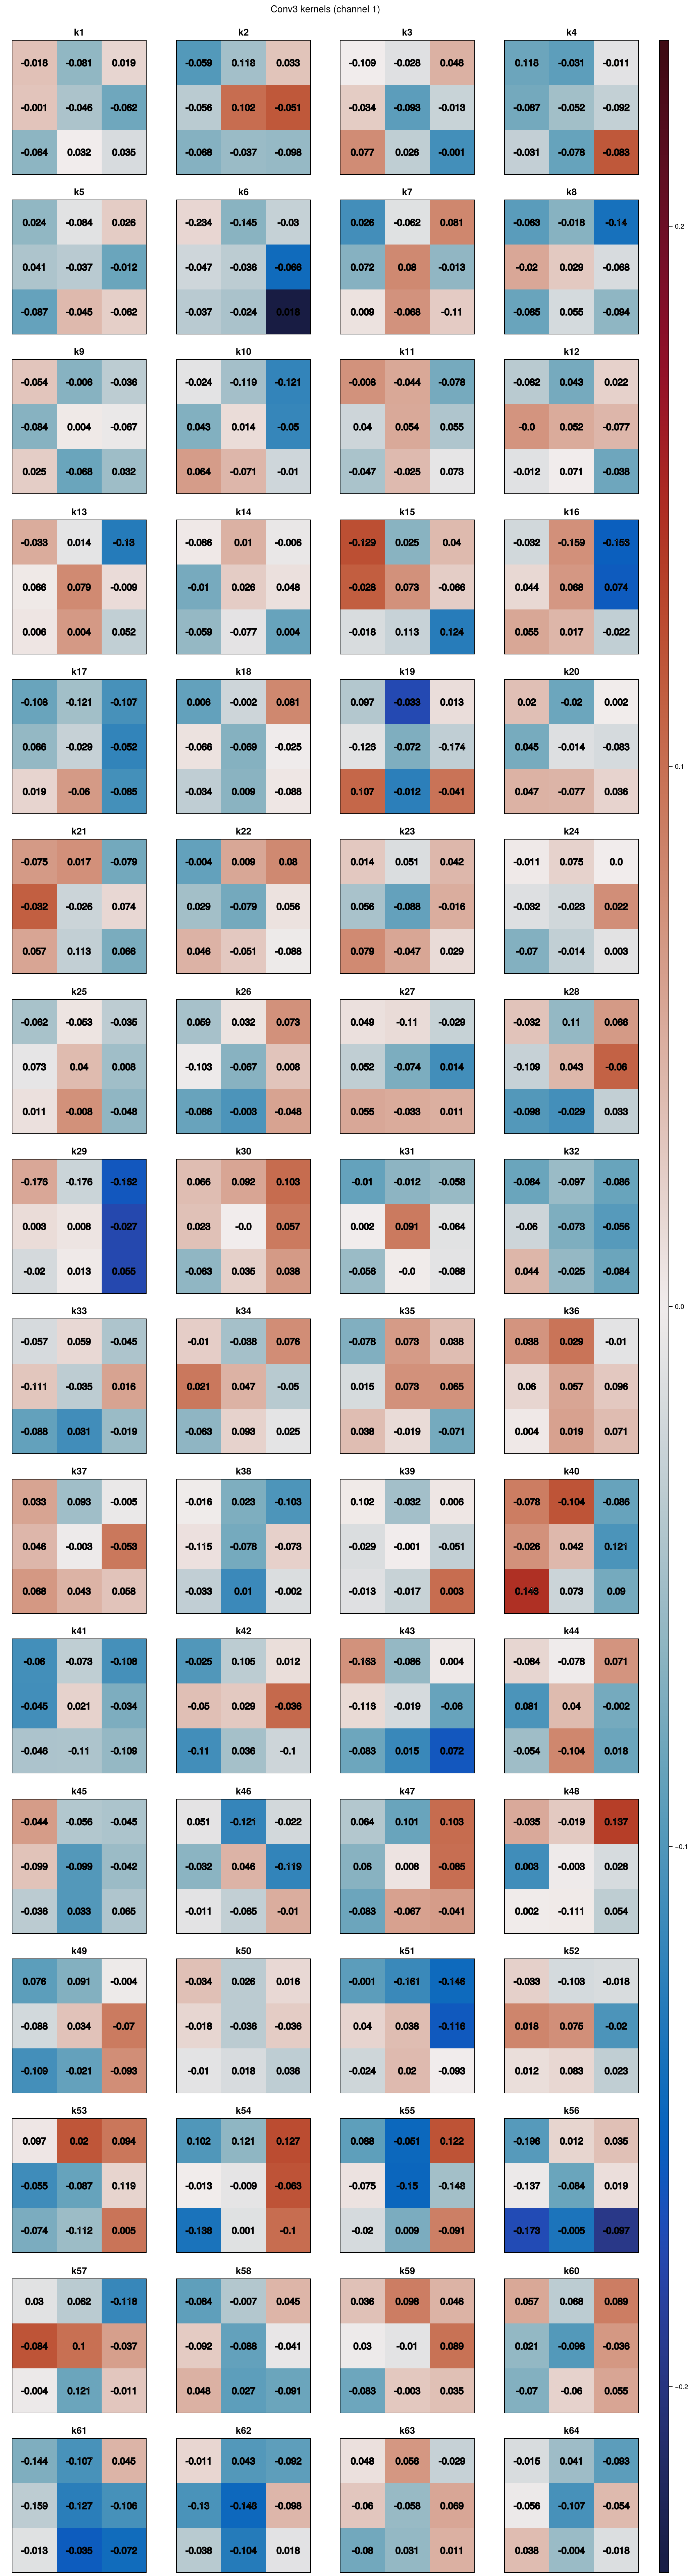


Conv1 kernel values (mean over channels):
Kernel 1:
Float32[0.0856 -0.0898 -0.2561; 0.324 -0.165 -0.2006; 0.0621 -0.0223 -0.08]
Kernel 2:
Float32[-0.1312 0.0603 -0.0434; -0.0492 0.0181 0.0955; 0.1897 0.2455 0.2644]
Kernel 3:
Float32[0.0953 -0.0353 -0.0946; 0.0111 0.166 0.1598; 0.0463 0.2092 0.3203]
Kernel 4:
Float32[-0.1396 -0.2431 -0.3079; -0.2904 -0.1828 0.023; -0.2503 -0.3095 -0.1301]
Kernel 5:
Float32[0.0598 -0.16 -0.002; 0.2404 0.1405 0.1652; 0.106 0.1766 -0.0957]
Kernel 6:
Float32[0.0421 0.2833 0.2824; 0.2375 0.1774 0.2997; -0.0385 -0.1186 0.2001]
Kernel 7:
Float32[-0.1373 0.015 -0.2648; -0.2145 -0.0699 -0.0938; -0.0431 0.0198 0.2182]
Kernel 8:
Float32[0.0222 -0.1843 0.1322; -0.0165 -0.3301 -0.2788; -0.3641 -0.1016 -0.0862]
Kernel 9:
Float32[-0.1595 0.1321 -0.19; 0.0067 -0.2603 -0.2532; 0.0603 -0.0934 0.1236]
Kernel 10:
Float32[0.1623 -0.1187 -0.3389; 0.1938 0.0845 -0.2864; 0.285 -0.1781 -0.2443]
Kernel 11:
Float32[0.1235 0.2493 0.2441; -0.0859 0.2623 0.2977; 0.2056 -0.0475 0.04

In [17]:
using CairoMakie

CairoMakie.activate!()

# Extract kernel images from a convolutional weight tensor.
function kernel_images(w; max_kernels=typemax(Int), channel=:mean)
    w_cpu = Array(cpu(w))
    kh, kw, cin, cout = size(w_cpu)
    nshow = min(max_kernels, cout)
    imgs = Vector{Matrix{Float32}}(undef, nshow)
    for i in 1:nshow
        k = w_cpu[:, :, :, i]
        if channel === :mean
            imgs[i] = dropdims(mean(k; dims=3), dims=3)
        else
            ch = clamp(Int(channel), 1, cin)
            imgs[i] = k[:, :, ch]
        end
    end
    return imgs
end

# Add numeric annotations to a heatmap.
function annotate_heatmap!(ax, mat, vmax; digits=3)
    rows, cols = size(mat)
    for r in 1:rows
        for c in 1:cols
            val = round(mat[r, c]; digits=digits)
            fg = abs(val) > 0.45 * vmax ? :white : :black
            text!(ax, c, r;
                text=string(val),
                align=(:center, :center),
                color=fg,
                strokecolor=:black,
                strokewidth=1.2,
                fontsize=14,
            )
        end
    end
end

# Plot convolutional kernels as heatmaps.
function plot_kernels(w; title="", max_kernels=typemax(Int), channel=:mean, digits=3)
    imgs = kernel_images(w; max_kernels=max_kernels, channel=channel)
    nshow = length(imgs)
    ncols = min(4, nshow)
    nrows = cld(nshow, ncols)

    fig = Figure(size=(240 * ncols + 70, 240 * nrows), figure_padding=5)
    colgap!(fig.layout, 8)
    rowgap!(fig.layout, 8)

    vmax = maximum(abs, reduce(hcat, vec.(imgs)))
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)

    hm_ref = nothing

    for (i, img) in enumerate(imgs)
        row = cld(i, ncols)
        col = i - (row - 1) * ncols
        ax = Axis(fig[row, col];
            title="k" * string(i),
            aspect=AxisAspect(1),
            xticksvisible=false,
            yticksvisible=false,
            xticklabelsvisible=false,
            yticklabelsvisible=false,
        )

        show_img = permutedims(img, (2, 1))

        hm = heatmap!(ax, show_img;
            colormap=:balance,
            colorrange=cr,
        )
        annotate_heatmap!(ax, show_img, vmax; digits=digits)
        hm_ref === nothing && (hm_ref = hm)
    end

    if !isempty(title)
        Label(fig[0, 1:ncols], title; tellwidth=false)
    end

    if hm_ref !== nothing
        Colorbar(fig[1:nrows, ncols+1], hm_ref; width=14, ticklabelsize=10)
    end

    return fig
end

# Print kernel values to the console.
function print_kernels(w; max_kernels=typemax(Int), channel=:mean, digits=4)
    w_cpu = Array(cpu(w))
    kh, kw, cin, cout = size(w_cpu)
    nshow = min(max_kernels, cout)
    for i in 1:nshow
        k = w_cpu[:, :, :, i]
        mat = channel === :mean ? dropdims(mean(k; dims=3), dims=3) : k[:, :, clamp(Int(channel), 1, cin)]
        println("Kernel ", i, ":")
        println(round.(mat, digits=digits))
    end
end

conv1 = model[1][1].weight
conv2 = model[2][1].weight
conv3 = model[3][1].weight

fig1 = plot_kernels(conv1; title="Conv1 kernels (mean over channels)", max_kernels=typemax(Int), digits=3)
fig2 = plot_kernels(conv2; title="Conv2 kernels (channel 1)", max_kernels=typemax(Int), channel=1, digits=3)
fig3 = plot_kernels(conv3; title="Conv3 kernels (channel 1)", max_kernels=typemax(Int), channel=1, digits=3)

display(fig1)
display(fig2)
display(fig3)

println("\nConv1 kernel values (mean over channels):")
print_kernels(conv1; max_kernels=typemax(Int), channel=:mean)

println("\nConv2 kernel values (channel 1):")
print_kernels(conv2; max_kernels=typemax(Int), channel=1)

println("\nConv3 kernel values (channel 1):")
print_kernels(conv3; max_kernels=typemax(Int), channel=1)

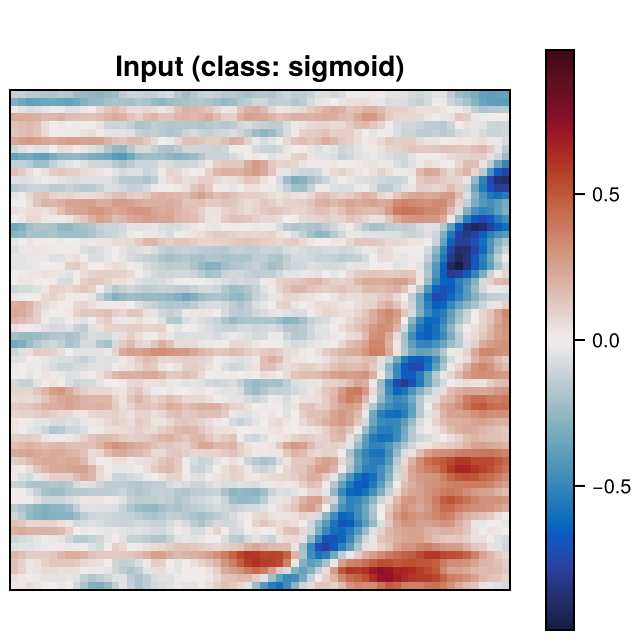

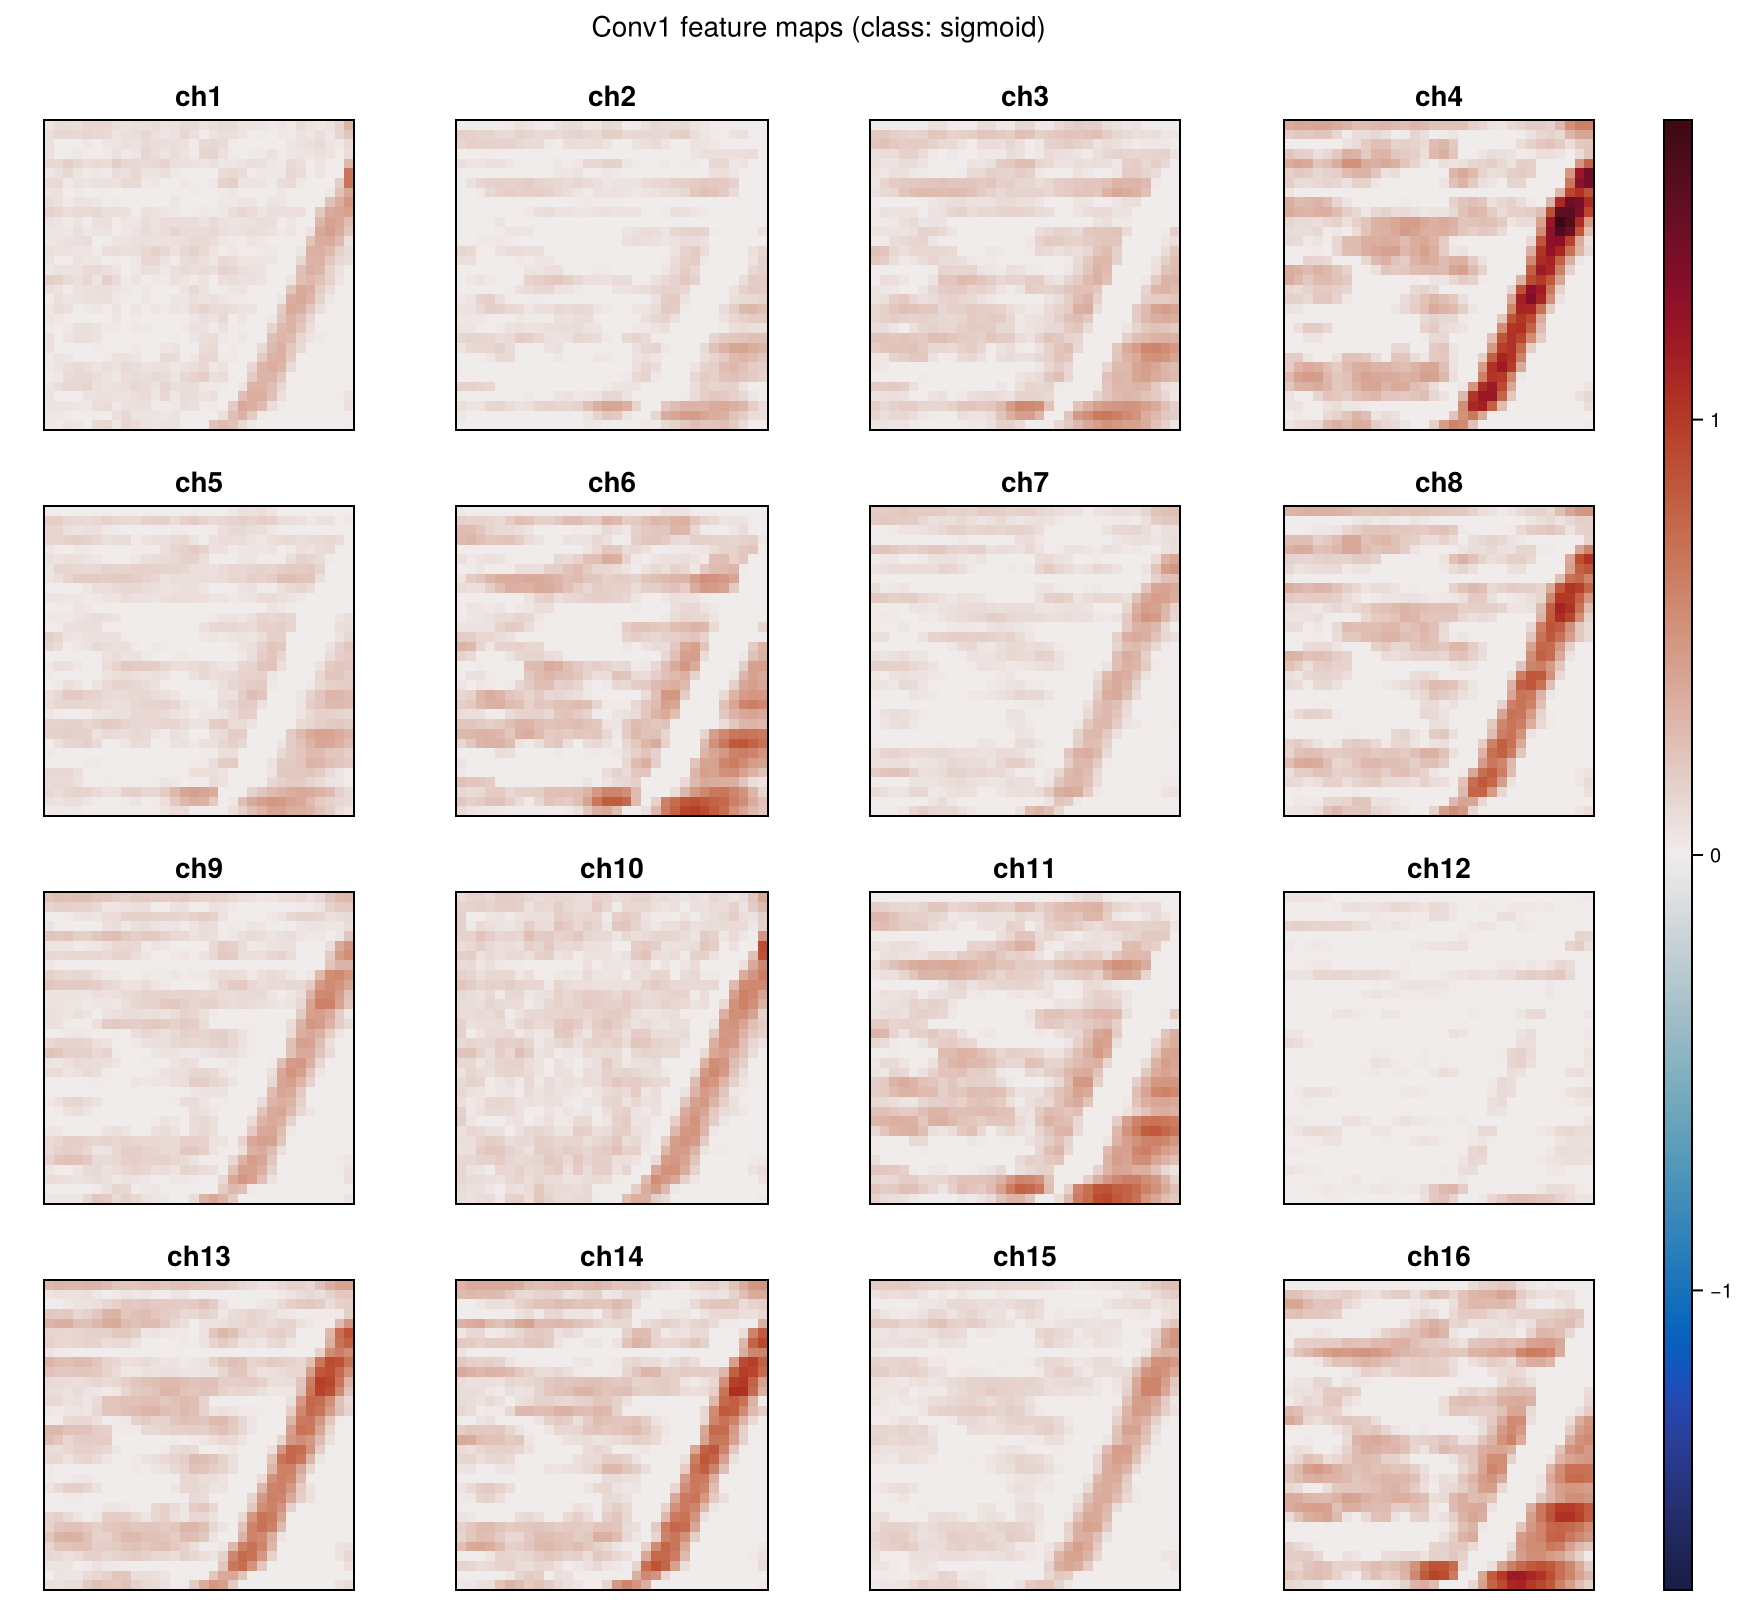

CairoMakie.Screen{IMAGE}


In [18]:
using CairoMakie

CairoMakie.activate!()

# Random test sample (fixed for all feature-map plots below)
sample_idx = rand(1:size(test_X, 4))

x0 = test_X[:, :, :, sample_idx:sample_idx]
x0_dev = device(x0)

block1_dev, block2_dev, block3_dev = model[1], model[2], model[3]

feat1 = Array(cpu(block1_dev(x0_dev)))
feat2 = Array(cpu(block2_dev(block1_dev(x0_dev))))
feat3 = Array(cpu(block3_dev(block2_dev(block1_dev(x0_dev)))))

input_img = Array(cpu(x0))[:, :, 1, 1]

# Resolve class name for a sample index.
function class_name_for(idx)
    if isdefined(Main, :y_true)
        return string(pattern_names[y_true[idx]+1])
    end
    if isdefined(Main, :test_Y)
        lbl = onecold(test_Y[:, idx], 0:length(pattern_names)-1)
        return string(pattern_names[lbl+1])
    end
    return "unknown"
end

class_name = class_name_for(sample_idx)

# Plot an input image with a colorbar.
function plot_input(img; title="Input")
    vmax = maximum(abs, img)
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)

    fig = Figure(size=(320, 320), figure_padding=5)
    ax = Axis(fig[1, 1];
        title=title,
        aspect=AxisAspect(1),
        xticksvisible=false,
        yticksvisible=false,
        xticklabelsvisible=false,
        yticklabelsvisible=false,
    )
    hm = heatmap!(ax, permutedims(img, (2, 1)); colormap=:balance, colorrange=cr)
    Colorbar(fig[1, 2], hm; width=14, ticklabelsize=10)
    return fig
end

# Plot a grid of feature maps.
function plot_feature_grid(feat; title="")
    nshow = size(feat, 3)
    ncols = nshow <= 16 ? 4 : nshow <= 64 ? 8 : 10
    nrows = cld(nshow, ncols)
    tile = nshow <= 16 ? 200 : nshow <= 64 ? 140 : 120

    vmax = maximum(abs, feat)
    vmax = vmax == 0 ? 1f-6 : vmax
    cr = (-vmax, vmax)

    fig = Figure(size=(tile * ncols + 70, tile * nrows), figure_padding=5)
    colgap!(fig.layout, 6)
    rowgap!(fig.layout, 6)

    hm_ref = nothing
    for i in 1:nshow
        row = cld(i, ncols)
        col = i - (row - 1) * ncols
        ax = Axis(fig[row, col];
            title="ch" * string(i),
            aspect=AxisAspect(1),
            xticksvisible=false,
            yticksvisible=false,
            xticklabelsvisible=false,
            yticklabelsvisible=false,
        )
        img = feat[:, :, i, 1]
        hm = heatmap!(ax, permutedims(img, (2, 1)); colormap=:balance, colorrange=cr)
        hm_ref === nothing && (hm_ref = hm)
    end

    if !isempty(title)
        Label(fig[0, 1:ncols], title; tellwidth=false)
    end

    if hm_ref !== nothing
        Colorbar(fig[1:nrows, ncols+1], hm_ref; width=14, ticklabelsize=10)
    end

    return fig
end

display(plot_input(input_img; title="Input (class: " * class_name * ")"))
display(plot_feature_grid(feat1; title="Conv1 feature maps (class: " * class_name * ")"))

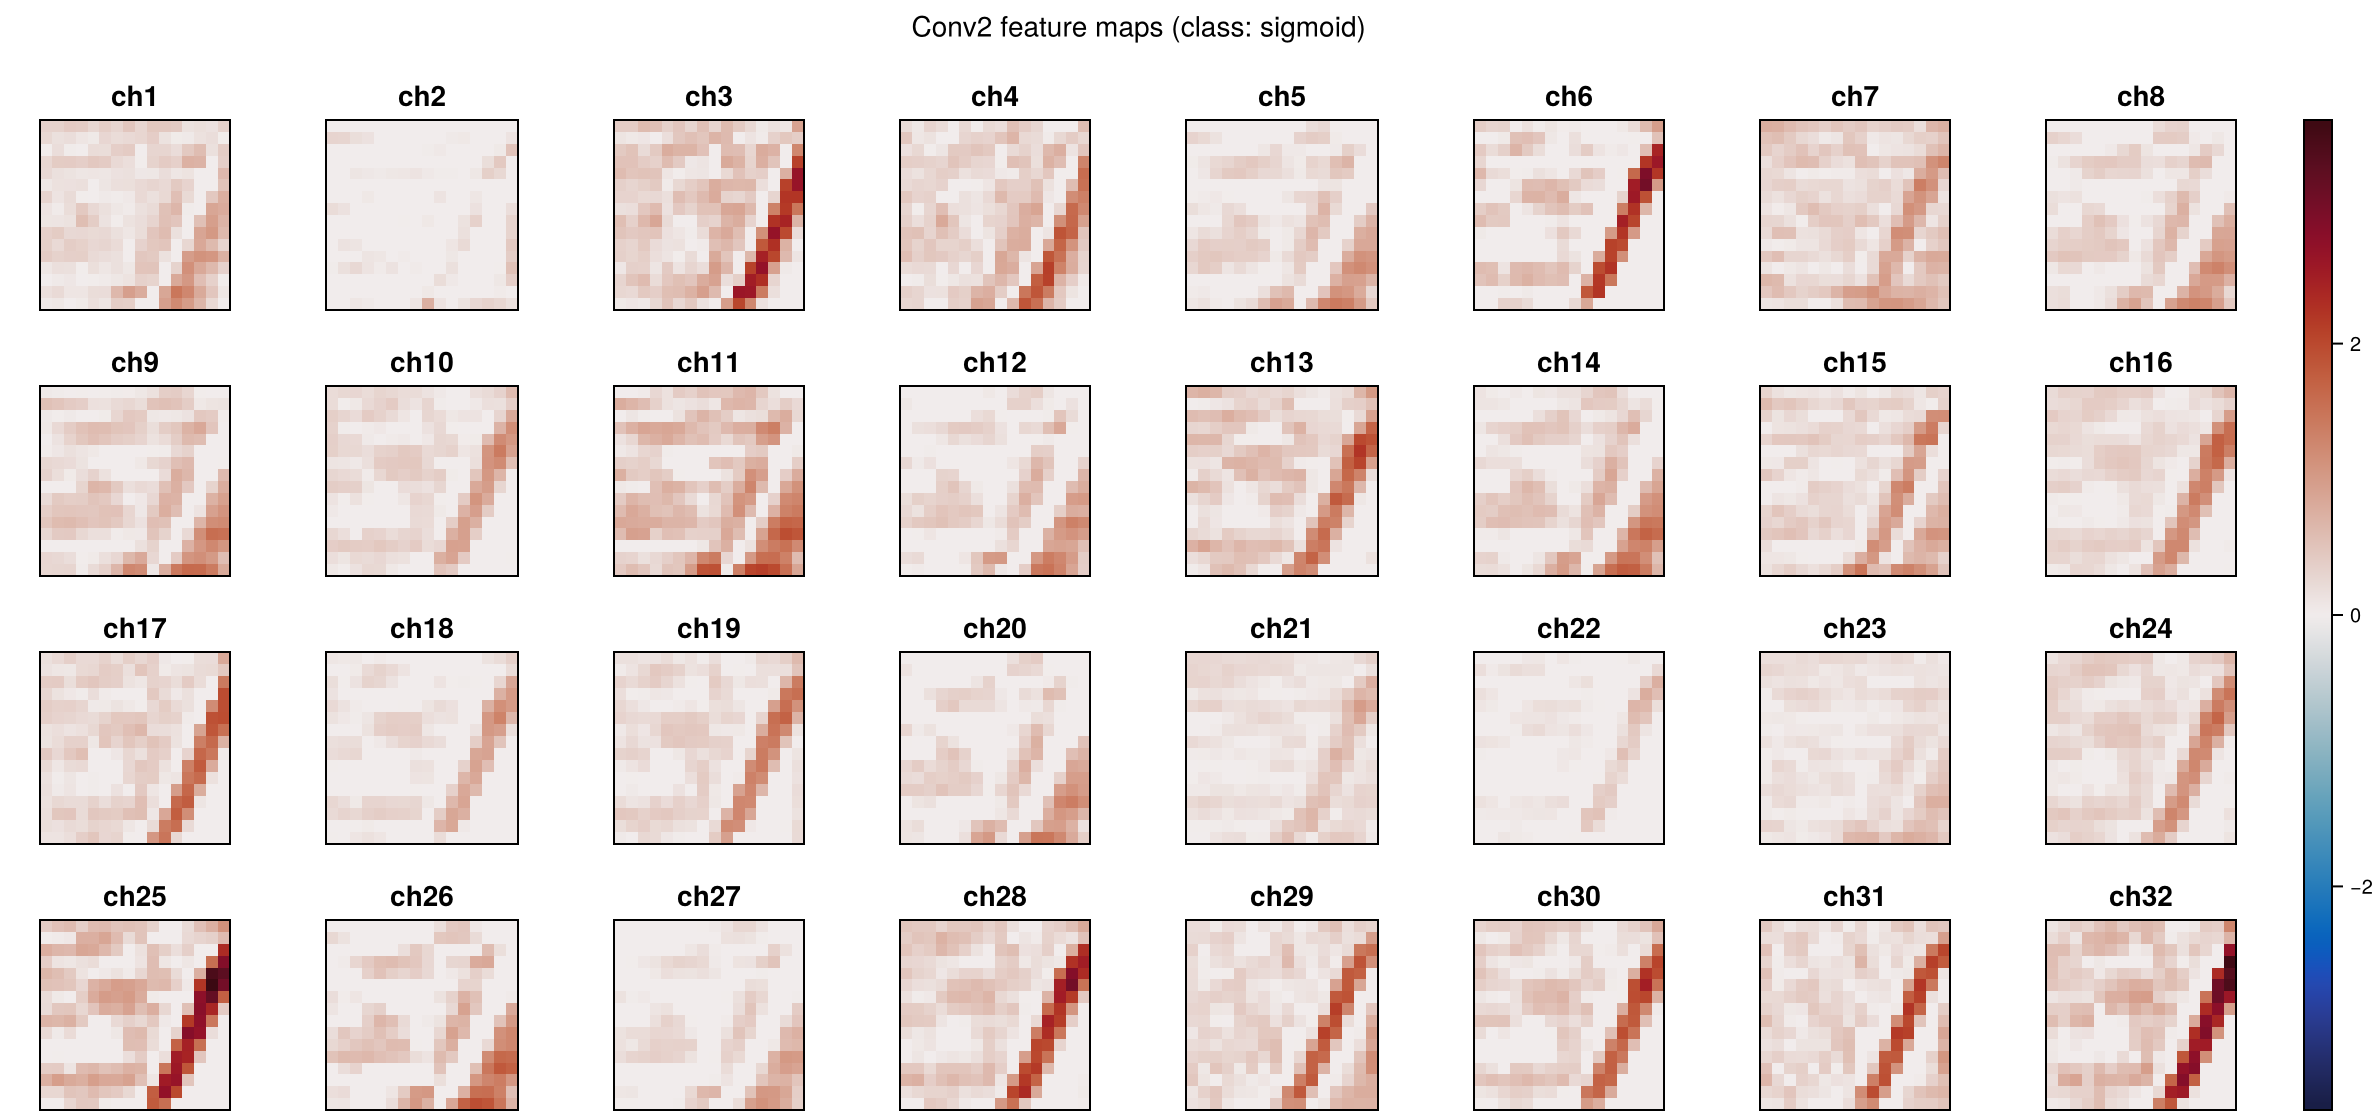

CairoMakie.Screen{IMAGE}


In [19]:
using CairoMakie

# Uses sample_idx, feat2, plot_feature_grid from the previous cell

display(plot_feature_grid(feat2; title="Conv2 feature maps (class: " * class_name * ")"))

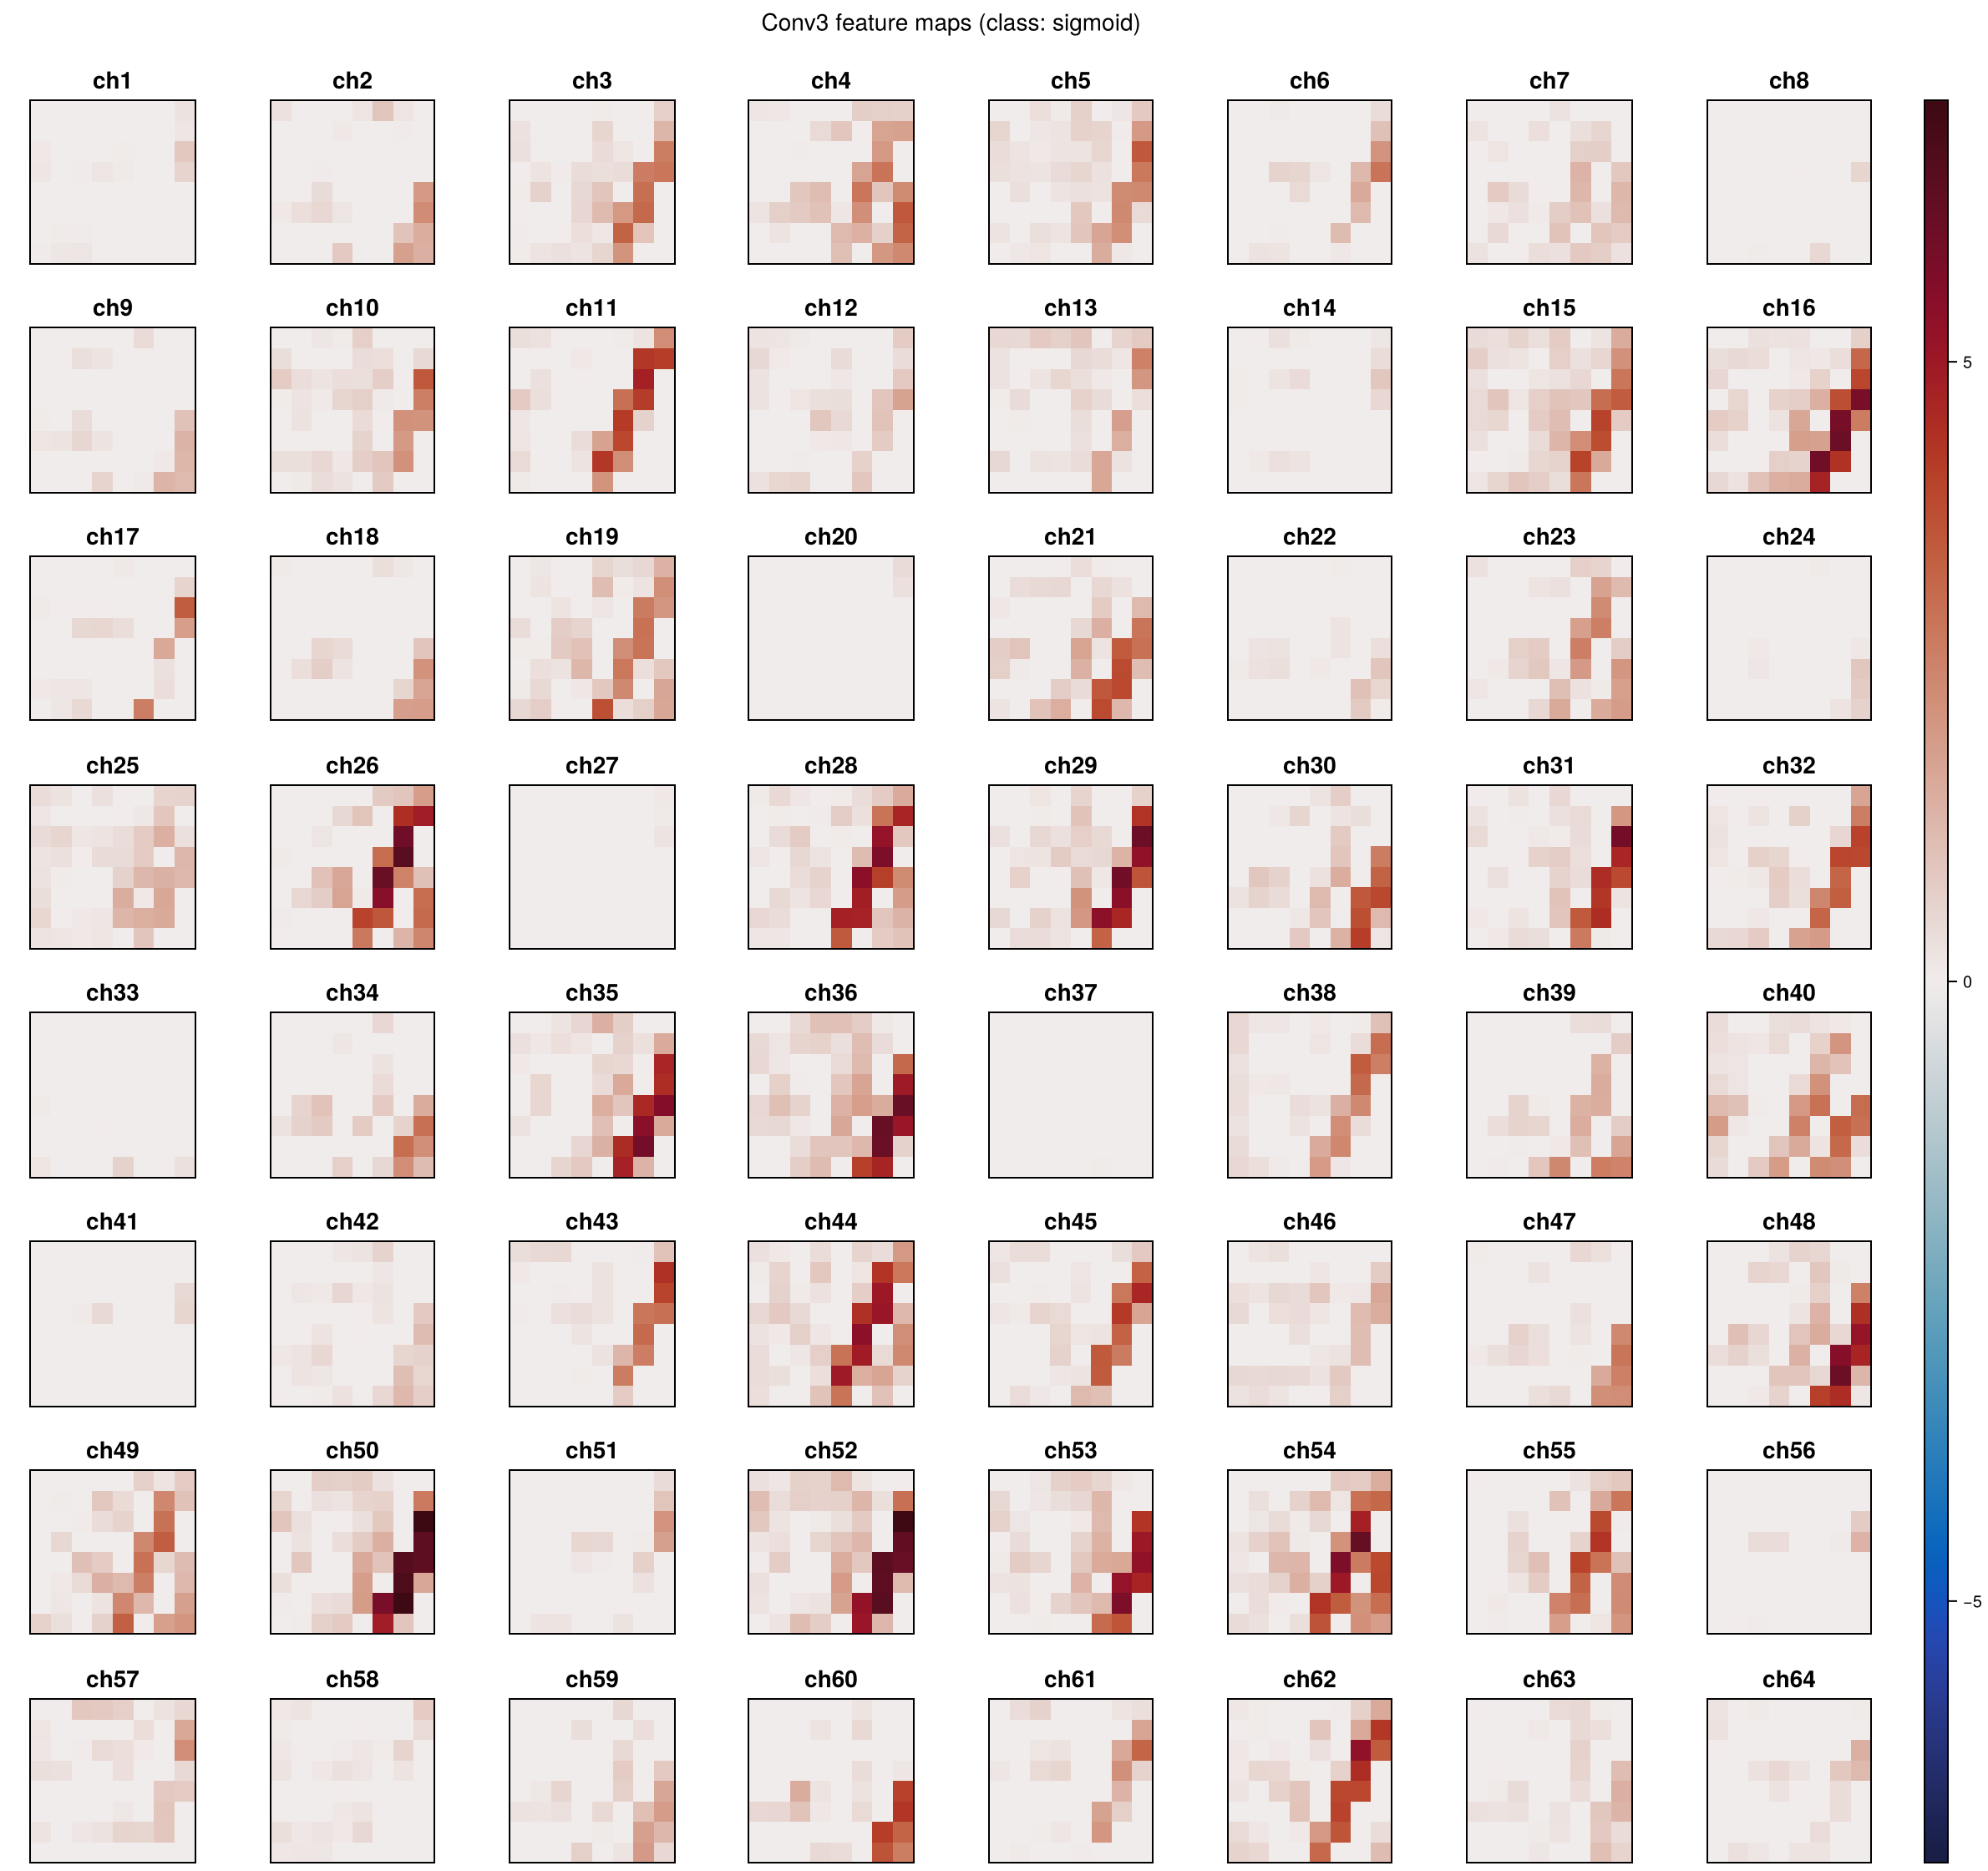

CairoMakie.Screen{IMAGE}


In [20]:
using CairoMakie

# Uses sample_idx, feat3, plot_feature_grid from the previous cell

display(plot_feature_grid(feat3; title="Conv3 feature maps (class: " * class_name * ")"))

In [22]:
using JLD2, Dates, Flux

model_dir = abspath(joinpath(pwd(), "..", "model_test"))
mkpath(model_dir)

stamp = Dates.format(now(), "yyyymmdd_HHMMSS")
model_path = joinpath(model_dir, "cnn_model_" * stamp * ".jld2")

model_cpu = cpu(model)

jldsave(model_path;
    model=model_cpu,
    model_state=Flux.state(model_cpu),
    pattern_names=pattern_names,
    variant_names=variant_names === nothing ? Symbol[] : variant_names,
    saved_at=stamp,
)

println("Saved model to: ", model_path)

Saved model to: /home/benjamin/Dokumente/BA2/notebooks/model_test/cnn_model_20260109_002206.jld2
